# NP2 channel-map geometry checker (`channel_positions.npy`)

This notebook helps you verify that each probe's Kilosort geometry matches the channel map you intended to use.

It will:
- load `channel_positions.npy` (and optionally `channel_map.npy`),
- plot the physical channel layout,
- summarize x/y spacing statistics,
- estimate a **suggested** `nChannelsIsoDist` range for BombCell.


In [1]:
from pathlib import Path
import re
from typing import Any, Dict
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import sys
import numpy as np
import pandas as pd
import importlib
import subprocess
import os
from dotenv import load_dotenv

plt.rcParams['figure.dpi'] = 120

import bombcell as bc

# ============= Load in configuration and helper functions =============
# Add MOUSE_NAME directory to path
mouse_dir = Path().resolve().parent.parent  # notebook in analyze_bc_results/
print("Notebook:", Path().resolve())
print("Added to sys.path:", mouse_dir)
print("Exists:", mouse_dir.exists())
print("Contents:", [p.name for p in mouse_dir.iterdir()])
sys.path.append(str(Path().resolve().parent))  # adds .../mice/Reach15

print("CWD:", Path().resolve())
print("sys.path[0:5]:", sys.path[0:5])
print("Has Reach15/grant_config.py?:", (Path().resolve().parent / "grant_config.py").exists())
print("Has Reach15/helper_func/grant_config.py?:", (Path().resolve().parent / "helper_func" / "grant_config.py").exists())

import helper_func.prep_data as data_prep
import helper_func.nwb_data_prep as prep
import helper_func.load_ch_geometry as ch_geometry
from helper_func.grant_config import load_grant_config
from helper_func.post_analysis_setup import load_post_analysis_context

# Always reload local modules so notebook uses latest patched code.
prep = importlib.reload(prep)
# plots = importlib.reload(plots)

print('pca_data_prep path:', Path(prep.__file__).resolve())
if not hasattr(prep, 'extract_probe_letters'):
    raise AttributeError(
        'Loaded pca_data_prep does not expose extract_probe_letters. '
        'Restart kernel and re-run this cell, then confirm it points to master/pca_data_prep.py.'
    )


✅ ipywidgets available - interactive GUI ready
Notebook: C:\Users\user\Documents\github\bombcell\mice\Reach15\analyze_bc_results
Added to sys.path: C:\Users\user\Documents\github\bombcell\mice
Exists: True
Contents: ['Reach15']
CWD: C:\Users\user\Documents\github\bombcell\mice\Reach15\analyze_bc_results
sys.path[0:5]: ['c:\\Users\\user\\anaconda3\\envs\\bombcell\\python311.zip', 'c:\\Users\\user\\anaconda3\\envs\\bombcell\\DLLs', 'c:\\Users\\user\\anaconda3\\envs\\bombcell\\Lib', 'c:\\Users\\user\\anaconda3\\envs\\bombcell', '']
Has Reach15/grant_config.py?: False
Has Reach15/helper_func/grant_config.py?: True
pca_data_prep path: C:\Users\user\Documents\github\bombcell\mice\Reach15\helper_func\nwb_data_prep.py


### Load data from .env

In [2]:
session_data_dic = prep.load_env()
session_data_dic.keys()

MOUSE loaded: Reach15
-- Behavioral Files --
BEHAVIORAL_FOLDER loaded: grant_reach15_swingDoor-christie
-- Neuropixels Sessions --
Session 1: NP_FILE=Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01 DATE=20260129 SESSION=session003 BOMBCELL=bombcell_batch_20260305_1130
Session 2: NP_FILE=Reach15_20260129_session004_NP_Recording_02_2026-01-29_16-50-32 DATE=20260129 SESSION=session004 BOMBCELL=NA
Session 3: NP_FILE=Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00 DATE=20260201 SESSION=session007 BOMBCELL=bombcell_batch_20260304_1536
-- Config Defaults --
RECORDINGS_ROOT loaded: H:/Grant/Neuropixels/Kilosort_Recordings
OPEN_EPHYS_CONTINUOUS_SUBPATH loaded: Record Node 103/experiment1/recording1/continuous
STRUCTURE_OEBIN_SUBPATH loaded: Record Node 103/experiment1/recording1/structure.oebin
NP20_PROBES loaded: A,C,D


dict_keys(['MOUSE', 'BEHAVIORAL_FOLDER', 'NP_FILE', 'NWB_FILE', 'DATE', 'SESSION', 'BOMBCELL', 'NP_FILE_01', 'NWB_FILE_01', 'DATE_01', 'SESSION_01', 'BOMBCELL_01', 'NP_FILE_02', 'NWB_FILE_02', 'DATE_02', 'SESSION_02', 'BOMBCELL_02', 'RECORDINGS_ROOT', 'OPEN_EPHYS_CONTINUOUS_SUBPATH', 'STRUCTURE_OEBIN_SUBPATH', 'NP20_PROBES', 'RESULTS_PATH', 'RUN_DATES'])

#### =========================================================
## STEP 1: Select Neuropixel session to analyze
#### =========================================================

In [3]:
SESSION_TO_ANALYZE = 1

MOUSE, BEHAVIORAL_FOLDER, NP_FILE, NWB_FILE, DATE, SESSION, BOMBCELL = prep.session_to_analyze(
                                                                                        session_data_dic['MOUSE'], session_data_dic['BEHAVIORAL_FOLDER'], 
                                                                                        session_data_dic['NP_FILE'],session_data_dic['NWB_FILE'] ,session_data_dic['DATE'], session_data_dic['SESSION'],session_data_dic['BOMBCELL'],
                                                                                        session_data_dic['NP_FILE_01'], session_data_dic['NWB_FILE_01'], session_data_dic['DATE_01'], session_data_dic['SESSION_01'],session_data_dic['BOMBCELL_01'] ,
                                                                                        session_data_dic['NP_FILE_02'], session_data_dic['NWB_FILE_02'], session_data_dic['DATE_02'], session_data_dic['SESSION_02'],session_data_dic['BOMBCELL_02'],
                                                                                        session_selection=SESSION_TO_ANALYZE
                                                                                    )
                                                               


SESSION SELECTION:

NP_FILE: Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01
NWB_FILE: NA
DATE: 20260129
SESSION: session003
BEHAVIORAL_FOLDER: grant_reach15_swingDoor-christie
BOMBCELL: bombcell_batch_20260305_1130


### Set up bombcell path

In [4]:
BOMBCELL_ROOT_FOR_AUTO_BUILD, NWB_PATH, CONFIG_FILE, SESSION_NAME = data_prep.set_bc_paths(
session_data_dic, MOUSE,NWB_FILE, NP_FILE, BOMBCELL, BEHAVIORAL_FOLDER, DATE, SESSION, SESSION_TO_ANALYZE
)



AUTO-GENERATED SESSION CONFIG

Session selection: 1
Mouse root: C:\Users\user\Documents\github\bombcell\mice\Reach15\analyze_bc_results\mice\Reach15
Recording name: Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01
Wrote config: C:\Users\user\Documents\github\bombcell\mice\Reach15\analyze_bc_results\mice\Reach15\configs\grant_recording_config_20260129_session003.json
All required files/folders found.
NWB file: H:\NWB_OUT\NA
Bombcell root folder: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130
Session config file: C:\Users\user\Documents\github\bombcell\mice\Reach15\analyze_bc_results\mice\Reach15\configs\grant_recording_config_20260129_session003.json


In [5]:
# Configuration - CHANGE THESE VALUES FOR YOUR DATA
BOMBCELL = session_data_dic['BOMBCELL']
NP_FILE = session_data_dic['NP_FILE']
staging_root = fr'H:\Grant\Neuropixels\Kilosort_Recordings\{NP_FILE}\bombcell\{BOMBCELL}'
TARGET_PROBE = 'A' 

# Optional: Set to True to see detailed information about each unit's classification
VERBOSE = True

In [6]:
# Construct the recording folder path
root_recording_folder = fr"H:\Grant\Neuropixels\Kilosort_Recordings\{session_data_dic['NP_FILE']}"  # Replace with actual root path
recording_folder = os.path.join(root_recording_folder, "Record Node 103", "experiment1", "recording1", "continuous")

#root_behavior_path = fr"G:\Grant\neuropixels\behavioral_recordings\{BEHAVIORAL_FOLDER}"
# Example values (replace as needed)A
root_behavior_path = fr"G:\Grant\behavior_data\DLC_net\{session_data_dic['BEHAVIORAL_FOLDER']}"
behavioral_folder = os.path.join(root_behavior_path, session_data_dic['DATE'] ,session_data_dic['SESSION'])
print(f'behavioral_folder: {behavioral_folder}')
# Check if the recording folder exists
if not os.path.exists(recording_folder):
    raise FileNotFoundError(f"Recording folder not found: {recording_folder}")
else:
    print("Neuropixel Recording folder found:", recording_folder)


behavioral_folder: G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\20260129\session003
Neuropixel Recording folder found: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\Record Node 103\experiment1\recording1\continuous


In [7]:
# staging_root, save_subdir = mode_to_roots[RUN_MODE]
ks_dir = Path(root_recording_folder) / f'kilosort4_{TARGET_PROBE}'
save_path = ks_dir / 'bombcell' 

print('Kilosort directory:', ks_dir)
print('Bombcell save path:', save_path)
print()
print('TSV file will be saved to:', ks_dir / 'cluster_bc_classificationReason.tsv')

# Load the config 
ctx = load_post_analysis_context(CONFIG_FILE)

probe_letters = list(ctx['probeLetters'])
config_probe_letters = probe_letters

print('staging_root:', staging_root)
print('probes:', probe_letters)

Kilosort directory: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\kilosort4_A
Bombcell save path: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\kilosort4_A\bombcell

TSV file will be saved to: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\kilosort4_A\cluster_bc_classificationReason.tsv
staging_root: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130
probes: ['A', 'B', 'C', 'D', 'E', 'F']


In [8]:
# Configuration - CHANGE THESE VALUES FOR YOUR DATA
TARGET_PROBE = 'A'
BOMBCELL = session_data_dic['BOMBCELL']
NP_FILE = session_data_dic['NP_FILE']
staging_root = fr'H:\Grant\Neuropixels\Kilosort_Recordings\{NP_FILE}\bombcell\{BOMBCELL}'
ks_dir = Path(staging_root) / f'kilosort4_{TARGET_PROBE}'
save_path = ks_dir / 'bombcell'

probe_dirs = {}
missing_probes = []
for probe in probe_letters:
    ks_dir = Path(staging_root) / f'kilosort4_{probe}'
    save_path = ks_dir
    probe_dirs[probe] = save_path
    print(f'Loading probe {probe} from ks_dir: {ks_dir}')
    if not save_path.exists():
        print(f'Missing bombcell save_path for probe {probe}: {save_path}')
        missing_probes.append(probe)
        continue
probe_dirs


Loading probe A from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_A
Loading probe B from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_B
Loading probe C from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_C
Loading probe D from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_D
Loading probe E from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_E
Loading probe F from ks_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session0

{'A': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01/bombcell/bombcell_batch_20260305_1130/kilosort4_A'),
 'B': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01/bombcell/bombcell_batch_20260305_1130/kilosort4_B'),
 'C': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01/bombcell/bombcell_batch_20260305_1130/kilosort4_C'),
 'D': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01/bombcell/bombcell_batch_20260305_1130/kilosort4_D'),
 'E': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01/bombcell/bombcell_batch_20260305_1130/kilosort4_E'),
 'F': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01/bombcell/

## 1) Configure your Kilosort folders

Set one folder per probe (A/C/D etc.). Each folder should contain `channel_positions.npy`.


## 3) Run geometry checks for all probes


=== A ===
Kilosort folder: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_A
channels: 384
unique x: 8, unique y: 78
median dx: 32.00 um
median dy: 15.00 um
median NN distance: 15.00 um
p90 NN distance: 15.00 um
Suggested nChannelsIsoDist: 4-6 (Dense geometry: default 4 is usually reasonable)
No ROI depth configured for this probe, showing geometry only.


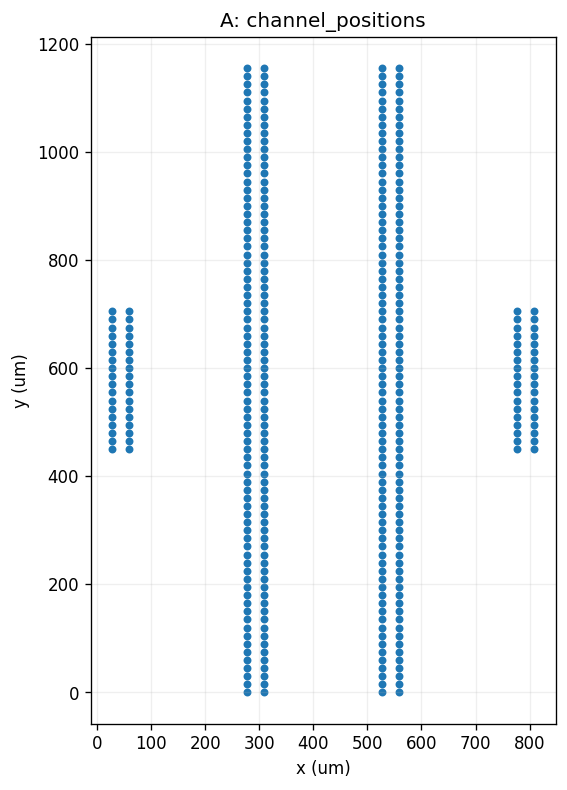


=== B ===
Kilosort folder: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_B
channels: 383
unique x: 4, unique y: 192
median dx: 16.00 um
median dy: 20.00 um
median NN distance: 25.61 um
p90 NN distance: 25.61 um
Suggested nChannelsIsoDist: 6-8 (Moderately sparse geometry: consider increasing from default 4)
No ROI depth configured for this probe, showing geometry only.


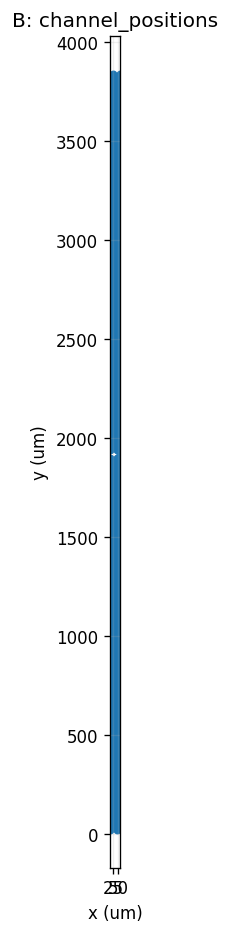


=== C ===
Kilosort folder: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_C
channels: 384
unique x: 8, unique y: 109
median dx: 32.00 um
median dy: 15.00 um
median NN distance: 30.00 um
p90 NN distance: 30.00 um
Suggested nChannelsIsoDist: 6-8 (Moderately sparse geometry: consider increasing from default 4)
No ROI depth configured for this probe, showing geometry only.


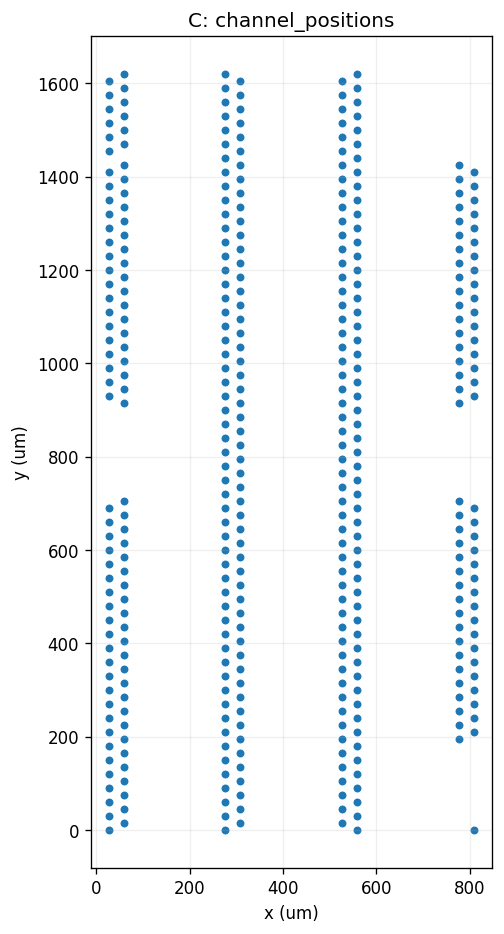


=== D ===
Kilosort folder: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_D
channels: 384
unique x: 8, unique y: 78
median dx: 32.00 um
median dy: 15.00 um
median NN distance: 15.00 um
p90 NN distance: 15.00 um
Suggested nChannelsIsoDist: 4-6 (Dense geometry: default 4 is usually reasonable)
No ROI depth configured for this probe, showing geometry only.


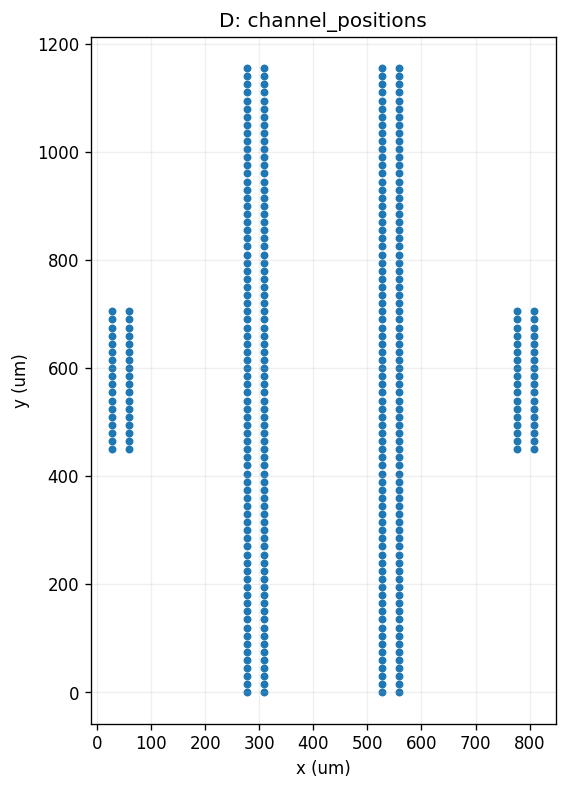


=== E ===
Kilosort folder: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_E
channels: 383
unique x: 4, unique y: 192
median dx: 16.00 um
median dy: 20.00 um
median NN distance: 25.61 um
p90 NN distance: 25.61 um
Suggested nChannelsIsoDist: 6-8 (Moderately sparse geometry: consider increasing from default 4)
No ROI depth configured for this probe, showing geometry only.


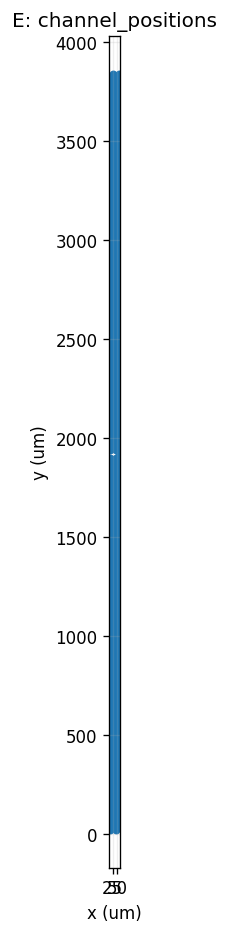


=== F ===
Kilosort folder: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_F
channels: 383
unique x: 4, unique y: 192
median dx: 16.00 um
median dy: 20.00 um
median NN distance: 25.61 um
p90 NN distance: 25.61 um
Suggested nChannelsIsoDist: 6-8 (Moderately sparse geometry: consider increasing from default 4)
No ROI depth configured for this probe, showing geometry only.


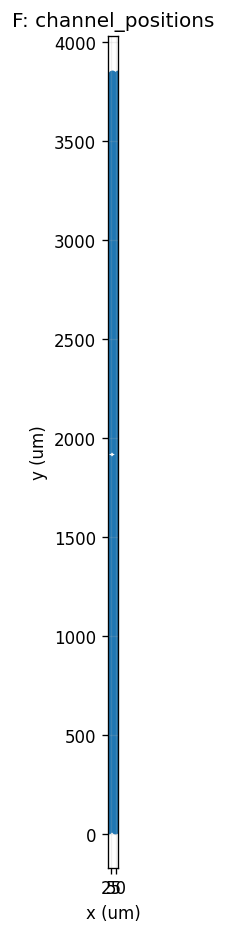

In [14]:
results = {}
probe_brain_regions = ctx.get("PROBE_BRAIN_REGIONS", {})
probe_recording_roi = ctx.get("PROBE_RECORDING_ROI", {})

for name, ks_dir in probe_dirs.items():
    print(f"\n=== {name} ===")
    if not (ks_dir / "channel_positions.npy").exists():
        print(f"Missing channel_positions.npy: {ks_dir}")
        continue

    channel_positions, channel_map = ch_geometry.load_geometry(ks_dir)
    summary, nn = ch_geometry.summarize_geometry(channel_positions)
    rec, note = ch_geometry.suggest_nChannelsIsoDist(summary)

    results[name] = {
        "ks_dir": ks_dir,
        "summary": summary,
        "nChannelsIsoDist_recommendation": rec,
        "recommendation_note": note,
    }

    print(f"Kilosort folder: {ks_dir}")
    print(f"channels: {summary['n_channels']}")
    print(f"unique x: {summary['n_unique_x']}, unique y: {summary['n_unique_y']}")
    print(f"median dx: {summary['median_dx']:.2f} um")
    print(f"median dy: {summary['median_dy']:.2f} um")
    print(f"median NN distance: {summary['median_nn_dist']:.2f} um")
    print(f"p90 NN distance: {summary['p90_nn_dist']:.2f} um")
    print(f"Suggested nChannelsIsoDist: {rec} ({note})")

    roi_end_um = probe_recording_roi.get(name)
    if roi_end_um is None:
        print("No ROI depth configured for this probe, showing geometry only.")
        ch_geometry.plot_geometry(channel_positions, title=f"{name}: channel_positions")
        continue

    roi_end_um = float(roi_end_um)
    details = ch_geometry.plot_roi_channel_comparison(
        channel_positions,
        probe_letter=name,
        roi_end_um=roi_end_um,
        out_label="OUT_ROI",
        probe_brain_regions=probe_brain_regions,
    )

    min_info = details["min_y"]
    max_info = details["max_y"]
    min_mask = min_info["in_roi_mask"]
    max_mask = max_info["in_roi_mask"]

    shared_in = int(np.sum(min_mask & max_mask))
    only_min = int(np.sum(min_mask & ~max_mask))
    only_max = int(np.sum(max_mask & ~min_mask))

    print(f"ROI depth (from tip): {roi_end_um:.1f} um")
    print("Brain-region depth bands from tip (um):")
    for band in max_info["region_bands"]:
        print(f"  {band['region']}: {float(band['start_um']):.1f} -> {float(band['end_um']):.1f}")

    for tip_position, info in (("min_y", min_info), ("max_y", max_info)):
        counts = pd.Series(info["roi_labels"]).value_counts().sort_index()
        print(f"ROI labels ({tip_position}):")
        for label, count in counts.items():
            print(f"  {label}: {int(count)}")

    print(f"Shared IN_ROI channels: {shared_in}")
    print(f"Only IN when using min_y: {only_min}")
    print(f"Only IN when using max_y: {only_max}")

    region_bands_text = ", ".join(
        [f"{b['region']}[{float(b['start_um']):.0f}-{float(b['end_um']):.0f}]" for b in max_info["region_bands"]]
    )

    results[name].update(
        {
            "roi_end_um": roi_end_um,
            "region_bands_um": region_bands_text,
            "in_channels_min_y": int(np.sum(min_mask)),
            "in_channels_max_y": int(np.sum(max_mask)),
            "in_channels_shared": shared_in,
            "in_channels_only_min_y": only_min,
            "in_channels_only_max_y": only_max,
        }
    )

## 4) Optional: quick comparison table

In [15]:
try:
    import pandas as pd
    rows = []
    for name, info in results.items():
        row = {
            "probe": name,
            **info["summary"],
            "nChannelsIsoDist_recommendation": info["nChannelsIsoDist_recommendation"],
            "note": info["recommendation_note"],
            "roi_end_um": info.get("roi_end_um", np.nan),
            "region_bands_um": info.get("region_bands_um", ""),
            "in_channels_min_y": info.get("in_channels_min_y", np.nan),
            "in_channels_max_y": info.get("in_channels_max_y", np.nan),
            "in_channels_shared": info.get("in_channels_shared", np.nan),
            "in_channels_only_min_y": info.get("in_channels_only_min_y", np.nan),
            "in_channels_only_max_y": info.get("in_channels_only_max_y", np.nan),
        }
        rows.append(row)
    display(pd.DataFrame(rows).sort_values("probe"))
except Exception as e:
    print("Pandas table skipped:", e)

,probe,n_channels,n_unique_x,n_unique_y,median_dx,median_dy,median_nn_dist,p90_nn_dist,nChannelsIsoDist_recommendation,note,roi_end_um,region_bands_um,in_channels_min_y,in_channels_max_y,in_channels_shared,in_channels_only_min_y,in_channels_only_max_y
0,A,384,8,78,32.0,15.0,15.000000,15.000000,4-6,Dense geometry: default 4 is usually reasonable,NaN,,NaN,NaN,NaN,NaN,NaN
1,B,383,4,192,16.0,20.0,25.612497,25.612497,6-8,Moderately sparse geometry: consider increasin...,NaN,,NaN,NaN,NaN,NaN,NaN
2,C,384,8,109,32.0,15.0,30.000000,30.000000,6-8,Moderately sparse geometry: consider increasin...,NaN,,NaN,NaN,NaN,NaN,NaN
3,D,384,8,78,32.0,15.0,15.000000,15.000000,4-6,Dense geometry: default 4 is usually reasonable,NaN,,NaN,NaN,NaN,NaN,NaN
4,E,383,4,192,16.0,20.0,25.612497,25.612497,6-8,Moderately sparse geometry: consider increasin...,NaN,,NaN,NaN,NaN,NaN,NaN
5,F,383,4,192,16.0,20.0,25.612497,25.612497,6-8,Moderately sparse geometry: consider increasin...,NaN,,NaN,NaN,NaN,NaN,NaN


## How to interpret for your specific NP2 patterns

Given your description:
- **Probe A** (`ON,OFF,OFF,OFF` interleaving): likely sparsest effective local neighborhood â†’ start around **8** (test 8â€“12).
- **Probe C** (`ON,OFF` interleaving): moderate sparsity â†’ start around **6** (test 6â€“8).
- **Probe D** (contiguous ON region): densest local neighborhood â†’ default **4** is usually acceptable (test 4â€“6).

Use the printed spacing stats and a small-unit QC comparison to decide final values.
